## A Multi-layer Model (MSM) of Notch-Delta Signalling

This notebook runs and analyzes the Multi-layer Signalling Model for Notch-Delta patterning on 3D epithelial topology data. It loads region-specific geometry and adjacency inputs, computes signalling outcomes across layers, evaluates SOP spacing and sensitivity to model parameters, and generates plots (saved to `figures/` when enabled).

To load your own dataset, provide for each `wing_region`:
- adjacency matrices in `data/adjacency_matrices/adjacency_matrices_<wing_region>.xlsx`
- cell geometry in `data/cell_geometry/cell_geometry_<wing_region>.csv`
- metadata in `data/wing_region_metadata.csv` (including region parameters and signalling labels)

For an example dataset structure, see the repository: [fberkemeier/MultiLayer-NotchDelta](https://github.com/fberkemeier/MultiLayer-NotchDelta).
Reference: [Paci et al., 2026](https://www.biorxiv.org/content/10.1101/2025.08.08.668674v1).
Full documentation is available [here]().


### 1. Dependencies and setup

#### Import MSM

In [1]:
# First, clone the GitHub repository at https://github.com/fberkemeier/MultiLayer-NotchDelta.git

import sys
from pathlib import Path

repo_root = Path.cwd()
if not (repo_root / 'src').exists():
    repo_root = repo_root.parent

sys.path.insert(0, str(repo_root / 'src'))
from msm_model import *


#### Data setup

In [2]:
# Wing disc labels from Paci et al. (2026)
wing_regions = ['wd_1', 'wd_2', 'wd_3', 'wd_1_mbs', 'wd_2_mbs', 'wd_3_mbs']
# Custom wing disc label
wing_regions = ['wd_1', 'wd_2', 'wd_3']

wing_discs = list_wing_discs(wing_regions)

signalling_labels_dict = load_signalling_labels_dict(wing_regions)
wd_dict = build_wd_label_dict(wing_regions)
gap_dict = build_gap_dict(wing_regions)
n_dict = build_n_layers_dict(wing_regions)
heights_dict = build_default_height_dict(wing_regions)

A_dict = build_adjacency_dict(wing_regions)
centroids_dict = build_centroids_dict(wing_regions)
area_apical_dict = build_area_apical_dict(wing_regions)
diam_apical_dict = build_diam_apical_dict(wing_regions)

signalling_labels_apical_dict = build_signalling_labels_apical_dict(
    wing_regions,
    signalling_labels_dict=signalling_labels_dict,
    adjacency_dict=A_dict,
)
apical_neighbours_dict = build_apical_neighbours_dict(
    wing_regions,
    signalling_labels_dict=signalling_labels_dict,
    adjacency_dict=A_dict,
)
nonapical_neighbours_dict = build_nonapical_neighbours_dict(
    wing_regions,
    signalling_labels_dict=signalling_labels_dict,
    adjacency_dict=A_dict,
)

# Notch intensity is now notebook-owned (user-editable per dataset)
notch_data = np.array([
    78.882, 70.702, 62.452, 55.169, 49.589, 44.339, 40.863, 38.124,
    35.518, 33.322, 31.955, 31.507, 30.938, 30.339, 29.484, 29.244,
    29.084, 28.970, 28.560, 28.366, 28.093, 28.167, 27.262, 26.740,
    26.212, 26.267, 27.035, 26.509, 26.545, 25.619, 26.036, 26.059,
    25.479, 25.472, 25.191, 25.506, 24.864, 24.734, 24.919, 25.314,
    26.016, 25.677, 25.618, 25.282, 25.482, 25.690, 25.258, 25.165,
    25.084, 25.022, 25.243, 25.178, 25.359, 25.294, 25.470, 25.763,
    25.659, 25.891, 25.820, 25.924, 26.172, 26.732, 26.190, 26.571
], dtype=float)

print(f"Loaded {len(wing_regions)} regions: {wing_regions}")


Loaded 3 regions: ['wd_1', 'wd_2', 'wd_3']


### 2. Simulations

#### Single simulation (graph plot)

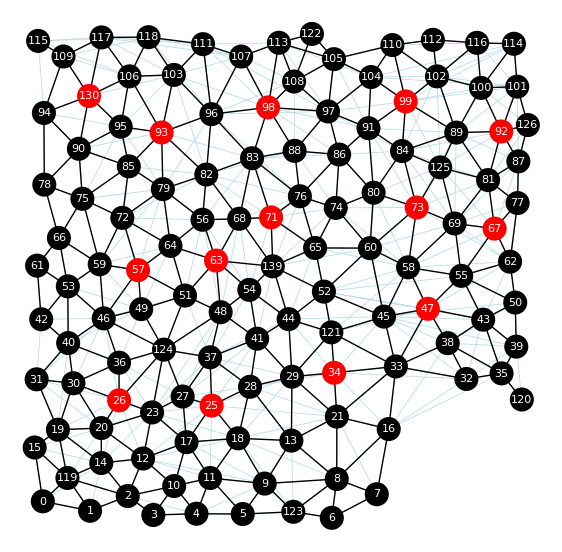

SOP spacing: 1.9583333333333333
Degenerate pattern: False


In [3]:
# Notch-Delta parameters
params = dict(k=2, h=8, Ka=10**-1, Kr=10**-3, nu=1, t_final=1000, hs=1.55, sim_number=1, omega_type='exp')
parser=argparse.ArgumentParser()
[parser.add_argument(f"--{n}",type=type(v),default=v,
                     choices=["exp","cnt","lin","exp0"] if n=="omega_type" else None)
 for n,v in params.items()]
args,_=parser.parse_known_args()
k,h,Ka,Kr,nu,t_final,hs,sim_number,omega_type=(
    args.k,args.h,args.Ka,args.Kr,args.nu,args.t_final,args.hs,args.sim_number,args.omega_type)
omega_func=omega_map[omega_type]
tag = f"{[k,h,Ka,Kr,nu,t_final,hs,omega_type]}"

# Heights
height_list = [height_set(diam_apical_dict[wingr], hs=hs) for wingr in wing_regions]
heights_dict = dict(zip(wing_regions, height_list))

# Wing disc
wing_region = 'wd_1' # Wing disc selection
Lmax = 300 # Signalling depth in μm

result = compute_band_distance(
    wing_region,
    omega_func=omega_func,
    Lmax=Lmax,
    sim_number=1,
    quad_method='simpson',
    height=heights_dict[wing_region],
    plotQ=True, graphsaveQ=False,
    normalQ=False,
    alpha=0,
    degen_T=1.,
    y_shift_steps=20,
    t_final=t_final,
    epsmodelQ=False, eps=0., prot_len=0.,
    k=k, h=h, Ka=Ka, Kr=Kr, nu=nu, dt=dt,
    randomQ=True
)
print(f"SOP spacing: {result[0][0.1]}\nDegenerate pattern: {result[2]}")


#### SOP spacing plots

Progress 45/90 | ETA 00:00:28

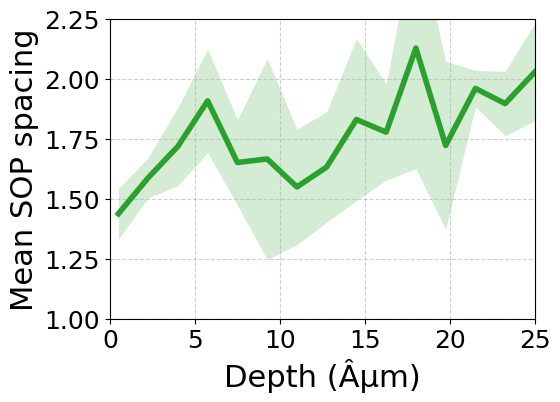

Progress 90/90 | ETA 00:00:00

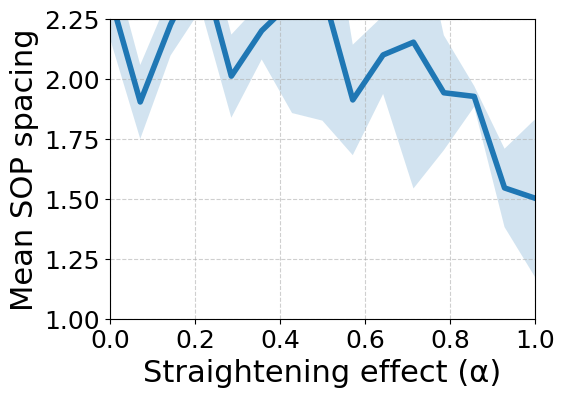

In [4]:
# Notch-Delta parameters
params = dict(k=2, h=8, Ka=10**-1, Kr=10**-3, nu=1., t_final=1000, hs=1.55, sim_number=1, omega_type='exp')
parser=argparse.ArgumentParser()
[parser.add_argument(f"--{n}",type=type(v),default=v,
                     choices=["exp","cnt","lin","exp0"] if n=="omega_type" else None)
 for n,v in params.items()]
args,_=parser.parse_known_args()
k,h,Ka,Kr,nu,t_final,hs,sim_number,omega_type=(
    args.k,args.h,args.Ka,args.Kr,args.nu,args.t_final,args.hs,args.sim_number,args.omega_type)
omega_func=omega_map[omega_type]
tag = f"{[k,h,Ka,Kr,nu,t_final,hs,omega_type]}"

# Heights
height_list = [height_set(diam_apical_dict[wingr], hs=hs) for wingr in wing_regions]
heights_dict = dict(zip(wing_regions, height_list))

# Wing discs
wing_regionsl = wing_regions # change as needed

# Other settings
threshold = 0.1
degen_T = 1.
normalQ = False
spsteps = 15

# ETA setup
t0 = time.time()
total_jobs = spsteps * 3 * 2
job_count = 0

# Spacing vs 3D contacts
Lmax_list = np.linspace(0.5, 25, spsteps)
spacing_dict_exp = {region: [] for region in wing_regionsl}
it = 0
for Lmax in Lmax_list:
    for region in wing_regionsl:
        d, vr, degenQ, avg_bimodal, _, _ = compute_band_distance(
            region,
            omega_func=omega_func,
            Lmax=Lmax,
            sim_number=sim_number,
            quad_method='simpson',
            height=heights_dict[region],
            degen_T=degen_T,
            normalQ=normalQ,
            t_final=t_final,
            y_shift_steps=20,
            k=k, h=h, Ka=Ka, Kr=Kr, nu=nu, dt=dt
        )
        d = d[threshold]; vr = vr[threshold]
        spacing_dict_exp[region].append([d, vr, degenQ])
        it += 1
        print(f"{it}/{len(Lmax_list)*len(wing_regionsl)}", end="\r")
        # ETA
        job_count += 1
        elapsed = time.time() - t0
        eta = (elapsed / job_count) * (total_jobs - job_count)
        print(f"Progress {job_count}/{total_jobs} | ETA {time.strftime('%H:%M:%S', time.gmtime(eta))}", end='\r')
fancy_plot(spacing_dict_exp, Lmax_list, 'exp', wing_regionsl, degenplotQ=True, ylim=(1.,2.25), errorbarQ=False,
           saveQ=True, title=f'sop_spacing_3D_{tag}', meancolor=shade("#2ca02c", 1), mergeQ=True)

# Spacing vs straightening
alpha_list = np.linspace(0., 1., spsteps)
spacing_dict_exp_straight = {region: [] for region in wing_regionsl}
it = 0
for alpha in alpha_list:
    for region in wing_regionsl:
        d, vr, degenQ, avg_bimodal, _, _ = compute_band_distance(
            region,
            omega_func=omega_exp,
            Lmax=25,
            alpha=alpha,
            sim_number=sim_number,
            quad_method='simpson',
            height=heights_dict[region],
            degen_T=degen_T,
            normalQ=normalQ,
            t_final=t_final,
            y_shift_steps=20,
            str_type='centroid',
            k=k, h=h, Ka=Ka, Kr=Kr, nu=nu, dt=dt
        )
        d = d[threshold]; vr = vr[threshold]
        spacing_dict_exp_straight[region].append([d, vr, degenQ])
        it += 1
        print(f"{it}/{len(alpha_list)*len(wing_regionsl)}", end="\r")
        # ETA
        job_count += 1
        elapsed = time.time() - t0
        eta = (elapsed / job_count) * (total_jobs - job_count)
        print(f"Progress {job_count}/{total_jobs} | ETA {time.strftime('%H:%M:%S', time.gmtime(eta))}", end='\r')
fancy_plot(spacing_dict_exp_straight, alpha_list, 'exp', wing_regionsl, degenplotQ=True, xlim=(0,1), ylim=(1.,2.25), errorbarQ=False,
           x_title='Straightening effect (α)', legend_loc='lower left',
           saveQ=True, title=f'sop_spacing_straight_{tag}', meancolor=shade("#1f77b4", 1), mergeQ=True)

### 3. Other analyses

#### 3D neighbour counts

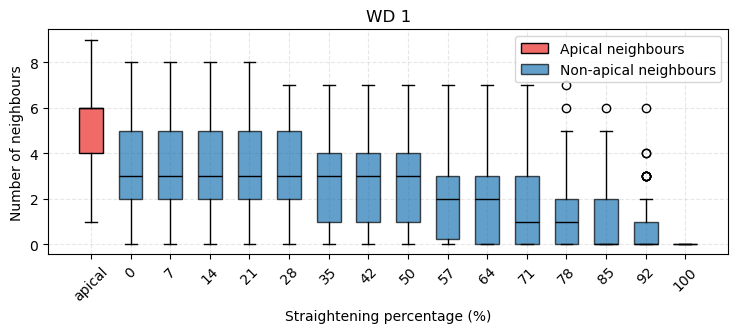

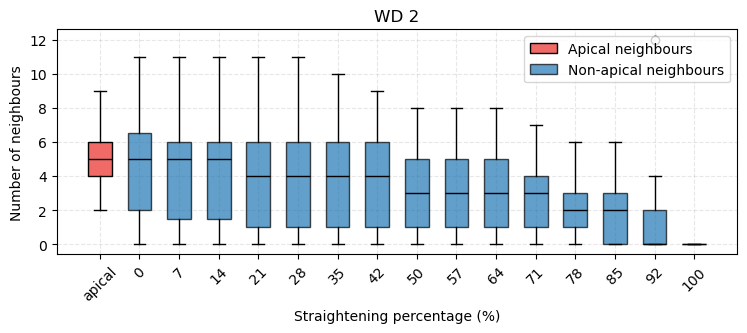

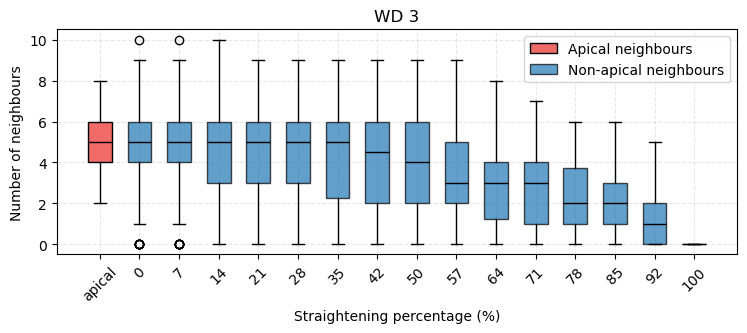

In [5]:
# number of neighbours vs straightening percentage
alphas = np.linspace(0,1,15)
A_str_dict = {
    α: straight_adjacency(A_dict, centroids_dict, α)
    for α in alphas
}
deg = {}
for wingr in wing_regions:
    deg[wingr] = plot_straightening_nonapical(A_str_dict, wingr, alphas, saveQ=False)


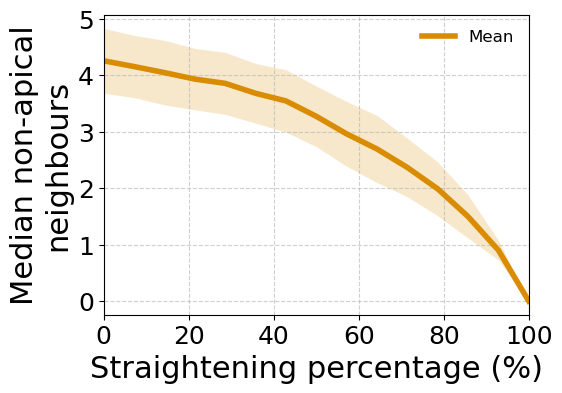

In [6]:
# comparison between mean neighbour change
deg_mean0 = {}
for wingr in wing_regions:
    deg_mean0[wingr] = [np.mean(i) for i in deg[wingr]]


deg_mean = np.array(list(deg_mean0.values()))
x = np.linspace(0, 100, 15)
line_color = "#D98C00"     # main curve colour
shade_color = "#D98C00"    # shading colour (can be different)
shade_alpha = 0.2          # shading transparency
mean_lw = 4                # line width
ymean = deg_mean.mean(axis=0)
ysd   = deg_mean.std(axis=0)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(x, ymean, color=line_color, linewidth=mean_lw, label="Mean")
ax.fill_between(
    x,
    ymean - ysd,
    ymean + ysd,
    color=shade_color,
    alpha=shade_alpha,
    linewidth=0
)
ax.set_xlabel("Straightening percentage (%)", fontsize=22)
ax.set_ylabel("Median non-apical\nneighbours", fontsize=22)
ax.tick_params(labelsize=18)
ax.set_xlim(0, 100)
ax.grid(True, linestyle="--", alpha=0.6)
leg = ax.legend(fontsize=12, frameon=False, loc="best")
leg.get_frame().set_facecolor("white")
leg.get_frame().set_alpha(0.8)
leg.get_frame().set_edgecolor("black")
leg.set_zorder(10)
ax.set_position([0.10, 0.15, 0.85, 0.75])
plt.savefig(FIGURES_DIR / "straight_neighbour_comparison.pdf",
            bbox_inches="tight", transparent=True)
plt.show()

#### Notch intensity fitting

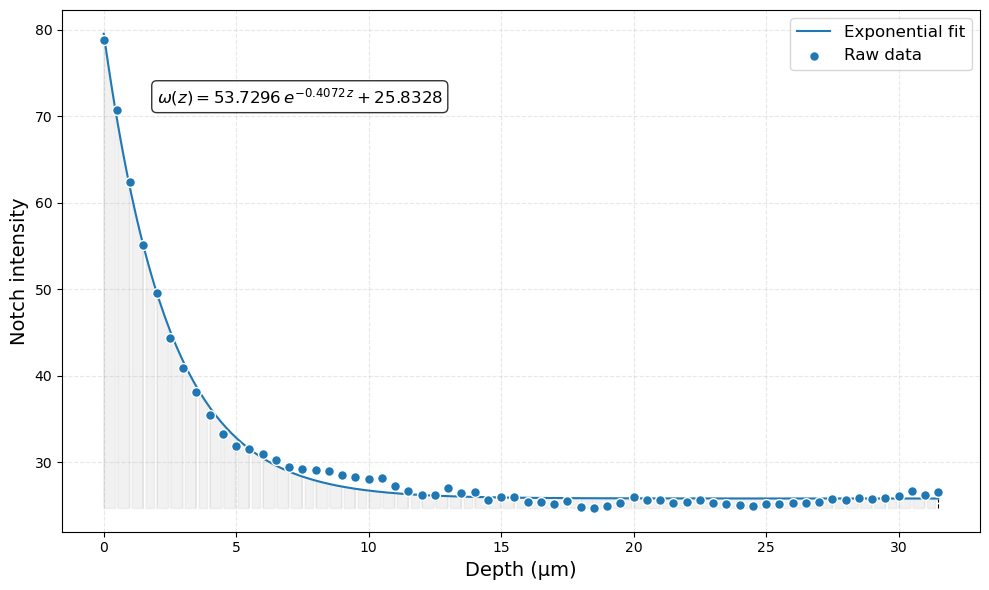

In [7]:
# Notch intensity fit
z = 0.5 * np.arange(len(notch_data))
omega = lambda z, A, B, C: A * np.exp(-B * z) + C
p0 = [notch_data[0] - notch_data[-1], 0.1, notch_data[-1]]
(A, B, C), _ = curve_fit(omega, z, notch_data, p0=p0)
gap = 0.5
zs = np.linspace(0, z.max(), 300)
fv = omega(zs, A, B, C)
y0 = np.nanmin(notch_data)
nb = int(z.max() / gap)
plt.figure(figsize=(10, 6))
plt.plot(zs, fv, color="#1f77b4", label="Exponential fit", zorder=2)
for i in range(nb):
    a, b = i * gap, (i + 1) * gap
    m = (zs >= a) & (zs < b)
    plt.fill_between(zs[m], fv[m], y0, color="lightgray", alpha=0.3, zorder=1)
    plt.plot([a, a], [y0, fv[np.argmin(np.abs(zs - a))]], color="black", lw=0.1, alpha=0.5, zorder=1)
xend = nb * gap
plt.plot([xend, xend], [y0, fv[np.argmin(np.abs(zs - xend))]], "k--", lw=0.8, zorder=1)
plt.scatter(z, notch_data, color="#1f77b4", edgecolor="white", s=50, zorder=3, label="Raw data")
eqn = rf"$\omega(z) = {A:.4f}\,e^{{-{B:.4f}\,z}} + {C:.4f}$"
plt.text(2, 0.9 * np.nanmax(fv), eqn, fontsize=12, bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
plt.xlabel("Depth (µm)", fontsize=14)
plt.ylabel("Notch intensity", fontsize=14)
plt.legend(loc="upper right", fontsize=12)
plt.grid(True, ls="--", alpha=0.3)
plt.tight_layout()
plt.show()


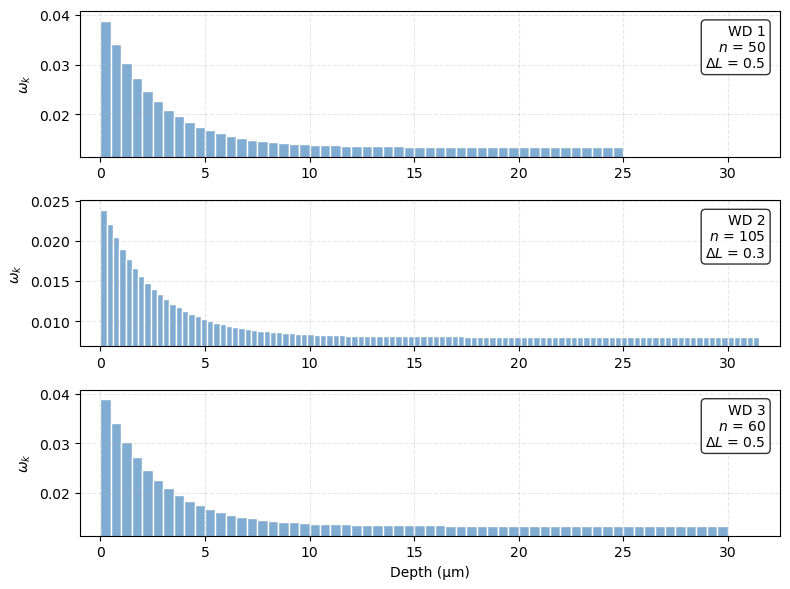

In [8]:
# Signalling weight histograms
I = A * (1 - np.exp(-B * 32)) / B + C * 32
A_new = A / I
C_new = C / I
B_new = B
omega_func = lambda z: A_new * np.exp(-B_new * z) + C_new
omega_k_dict = {}
for region in wing_regions:
    wk = compute_omega_k(
        omega_func,
        wing_region=region,
        Lmax=None,
        method='simpson',
        num_simpson=101
    )
    omega_k_dict[region] = wk

blueish = '#80ACD1'
regions = wing_regions
fig, axes = plt.subplots(len(regions), 1, figsize=(8, 6), sharex=False)

for ax, region in zip(axes, regions):
    wk  = omega_k_dict[region]
    gap = gap_dict[region]
    n   = len(wk)
    edges = np.arange(n) * gap  # left edge of each bar
    ax.bar(edges, wk,
           width=gap,
           align='edge',
           color=blueish,
           edgecolor='white')
    ax.set_xlim(-1, 32.5)
    ax.set_ylim(bottom=np.min(wk)*0.85)
    ax.set_ylabel(r'$\omega_k$')
    ax.grid(True, linestyle='--', alpha=0.3)
    info = f"WD {wd_dict[region]}\n" \
           f"$n$ = {n}\n" \
           r"$\Delta L$" f" = {gap}"
    props = dict(boxstyle="round", facecolor="white", alpha=0.8)
    ax.text(0.98, 0.91,
            info,
            transform=ax.transAxes,
            fontsize=10,
            ha="right",
            va="top",
            bbox=props)
axes[-1].set_xlabel('Depth (µm)')
plt.tight_layout()
plt.show()
